# Diamond Price Prediction — Regression

## Model 1: Multiple Linear Regression

Linear Regression is used first as a baseline. It estimates diamond price as a linear combination of the numerical measurements and encoded quality categories. Later models can be compared with this baseline using the same train/test split and evaluation metrics.

### Step 1 — Import the required libraries

In [52]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

### Step 2 — Load the diamond dataset

The path check lets this notebook run from either the project root or the `models/` directory.

In [53]:
data_path = "../data/diamond.csv"

diamonds = pd.read_csv(data_path)
print(f"Original shape: {diamonds.shape}")
diamonds.head()

Original shape: (53940, 10)


,Carat(Weight of Daimond),Cut(Quality),Color,Clarity,Depth,Table,Price(in US dollars),X(length),Y(width),Z(Depth)
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


### Step 3 — Rename columns for easier use

In [54]:
diamonds = diamonds.rename(
    columns={
        "Carat(Weight of Daimond)": "carat",
        "Cut(Quality)": "cut",
        "Color": "color",
        "Clarity": "clarity",
        "Depth": "depth",
        "Table": "table",
        "Price(in US dollars)": "price",
        "X(length)": "x",
        "Y(width)": "y",
        "Z(Depth)": "z",
    }
)
diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


### Step 4 — Inspect data quality

We check data types, missing values, duplicates, and descriptive statistics before modeling.

In [55]:
diamonds.info()

quality_report = pd.DataFrame(
    {
        "data_type": diamonds.dtypes.astype(str),
        "missing_values": diamonds.isna().sum(),
        "unique_values": diamonds.nunique(),
    }
)
print(f"Duplicate rows: {diamonds.duplicated().sum()}")
quality_report

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  str    
 2   color    53940 non-null  str    
 3   clarity  53940 non-null  str    
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.1 MB
Duplicate rows: 146


,data_type,missing_values,unique_values
carat,float64,0,273
cut,str,0,5
color,str,0,7
clarity,str,0,8
depth,float64,0,184
table,float64,0,127
price,int64,0,11602
x,float64,0,554
y,float64,0,552
z,float64,0,375


In [56]:
diamonds.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
carat,53940.0,NaN,NaN,NaN,0.79794,0.474011,0.2,0.4,0.7,1.04,5.01
cut,53940,5,Ideal,21551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
color,53940,7,G,11292,NaN,NaN,NaN,NaN,NaN,NaN,NaN
clarity,53940,8,SI1,13065,NaN,NaN,NaN,NaN,NaN,NaN,NaN
depth,53940.0,NaN,NaN,NaN,61.749405,1.432621,43.0,61.0,61.8,62.5,79.0
table,53940.0,NaN,NaN,NaN,57.457184,2.234491,43.0,56.0,57.0,59.0,95.0
price,53940.0,NaN,NaN,NaN,3932.799722,3989.439738,326.0,950.0,2401.0,5324.25,18823.0
x,53940.0,NaN,NaN,NaN,5.731157,1.121761,0.0,4.71,5.7,6.54,10.74
y,53940.0,NaN,NaN,NaN,5.734526,1.142135,0.0,4.72,5.71,6.54,58.9
z,53940.0,NaN,NaN,NaN,3.538734,0.705699,0.0,2.91,3.53,4.04,31.8


### Step 5 — Clean invalid physical measurements

A real diamond cannot have zero length, width, or depth. Rows with a zero in `x`, `y`, or `z` are removed. Missing-value imputers remain in the preprocessing pipeline so it is robust to future data.

In [57]:
dimension_columns = ["x", "y", "z"]
invalid_dimensions = (diamonds[dimension_columns] <= 0).any(axis=1)
print(f"Rows with invalid dimensions: {invalid_dimensions.sum()}")

diamonds_clean = diamonds.loc[~invalid_dimensions].copy()
print(f"Cleaned shape: {diamonds_clean.shape}")

Rows with invalid dimensions: 20
Cleaned shape: (53920, 10)


### Step 6 — Separate features and target

`price` is the continuous target. The remaining nine columns are input features.

In [58]:
X = diamonds_clean.drop(columns="price")
y = diamonds_clean["price"]

numerical_features = X.select_dtypes(include="number").columns.tolist()
categorical_features = X.select_dtypes(exclude="number").columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)
print("Target: price")

Numerical features: ['carat', 'depth', 'table', 'x', 'y', 'z']
Categorical features: ['cut', 'color', 'clarity']
Target: price


### Step 7 — Create the training and test sets

The same 80/20 split and random state should be retained for all ten models to make their scores directly comparable.

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")

Training rows: 43,136
Test rows: 10,784


### Step 8 — Build the preprocessing pipeline

Numerical columns are median-imputed and standardized. Categorical columns are mode-imputed and one-hot encoded. `drop='first'` avoids redundant dummy columns in a linear model. The transformer is fitted only on the training set through the pipeline, preventing data leakage.

In [60]:
numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", numerical_pipeline, numerical_features),
        ("categorical", categorical_pipeline, categorical_features),
    ]
)

### Step 9 — Train Model 1: Multiple Linear Regression

In [61]:
linear_regression_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression()),
    ]
)

linear_regression_model.fit(X_train, y_train)
print("Linear Regression training complete.")

Linear Regression training complete.


### Step 10 — Evaluate the model

- **R²:** Proportion of variation in diamond prices explained by the model; closer to 1 is better.
- **RMSE:** Typical prediction error in dollars, with larger errors penalized more heavily.
- **MAE:** Average absolute prediction error in dollars.

In [62]:
train_predictions = linear_regression_model.predict(X_train)
test_predictions = linear_regression_model.predict(X_test)

def regression_metrics(actual, predicted):
    return {
        "R2 Score": r2_score(actual, predicted),
        "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
        "MAE": mean_absolute_error(actual, predicted),
    }

train_metrics = regression_metrics(y_train, train_predictions)
test_metrics = regression_metrics(y_test, test_predictions)

pd.DataFrame([train_metrics, test_metrics], index=["Training set", "Test set"]).round(3)

,R2 Score,RMSE,MAE
Training set,0.919,1136.063,737.449
Test set,0.920,1135.944,726.300


In [63]:
results_df = pd.DataFrame(
    [
        {
            "Model": "Multiple Linear Regression",
            **test_metrics,
        }
    ]
).sort_values("R2 Score", ascending=False, ignore_index=True)

results_df.round(3)

,Model,R2 Score,RMSE,MAE
0,Multiple Linear Regression,0.92,1135.944,726.3


### Step 11 — Visualize predictions and residuals

A good model places points near the diagonal in the actual-versus-predicted plot. Residuals should be scattered around zero without a strong pattern.

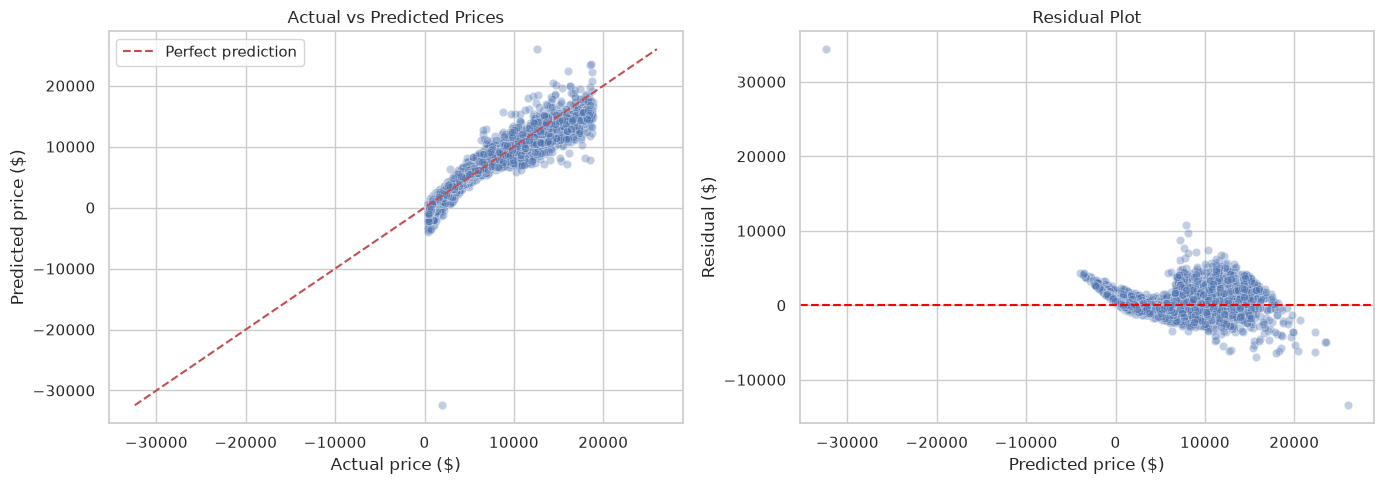

In [64]:
residuals = y_test - test_predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=y_test, y=test_predictions, alpha=0.35, ax=axes[0])
plot_min = min(y_test.min(), test_predictions.min())
plot_max = max(y_test.max(), test_predictions.max())
axes[0].plot([plot_min, plot_max], [plot_min, plot_max], "r--", label="Perfect prediction")
axes[0].set(title="Actual vs Predicted Prices", xlabel="Actual price ($)", ylabel="Predicted price ($)")
axes[0].legend()

sns.scatterplot(x=test_predictions, y=residuals, alpha=0.35, ax=axes[1])
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set(title="Residual Plot", xlabel="Predicted price ($)", ylabel="Residual ($)")

plt.tight_layout()
plt.show()

### Step 12 — Inspect the most influential coefficients

Because numerical inputs were standardized, their coefficients represent the change associated with one standard deviation. One-hot coefficients are relative to the category dropped by the encoder. Coefficients show association, not causation.

In [65]:
fitted_preprocessor = linear_regression_model.named_steps["preprocessor"]
feature_names = fitted_preprocessor.get_feature_names_out()
coefficients = linear_regression_model.named_steps["regressor"].coef_

coefficient_table = pd.DataFrame(
    {"Feature": feature_names, "Coefficient": coefficients}
)
coefficient_table["Absolute Coefficient"] = coefficient_table["Coefficient"].abs()
coefficient_table.sort_values("Absolute Coefficient", ascending=False).head(15)

,Feature,Coefficient,Absolute Coefficient
16,categorical__clarity_IF,5460.586819,5460.586819
0,numerical__carat,5415.021400,5415.021400
21,categorical__clarity_VVS1,5104.250639,5104.250639
22,categorical__clarity_VVS2,5055.121118,5055.121118
19,categorical__clarity_VS1,4698.845877,4698.845877
20,categorical__clarity_VS2,4392.848946,4392.848946
17,categorical__clarity_SI1,3780.837317,3780.837317
18,categorical__clarity_SI2,2832.865161,2832.865161
15,categorical__color_J,-2386.097819,2386.097819
14,categorical__color_I,-1477.176086,1477.176086


## Model 1 conclusion

Multiple Linear Regression provides the baseline scores for this project. Its assumptions can limit performance when the relationships between diamond attributes and price are nonlinear. The next model should be compared using the same cleaned data, split, preprocessing approach, and metrics.